## 0. Gerekli Kütüphaneler

In [1]:
# Gerekli paketleri yükle
!pip install google-play-scraper xgboost lightgbm shap -q

import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
from xgboost import XGBClassifier
import lightgbm as lgb

warnings.filterwarnings('ignore')

# ── Tekrarlanabilirlik için sabit değerler ──
RANDOM_STATE      = 42
POSITIVE_THRESHOLD = 4           # 4-5 yıldız → pozitif
TEST_SIZE         = 0.15
VALIDATION_SIZE   = 0.15
TOP_N_FEATURES    = 20

np.random.seed(RANDOM_STATE)
print('✓ Tüm kütüphaneler başarıyla yüklendi.')

✓ Tüm kütüphaneler başarıyla yüklendi.


---
## 1. Giriş ve Problem Tanımı

Kullanıcıların uygulama hakkındaki görüşlerini anlamak, uygulama geliştiriciler için kritik öneme sahiptir.
Bu projede, Google Play Store'dan toplanan ~54.000 Türkçe uygulama yorumu kullanılarak **otomatik sentiment sınıflandırması** yapılmaktadır.

**Hedef değişken:** Yorum puanı (1–5 yıldız)  
- **Pozitif (1):** 4 veya 5 yıldız  
- **Negatif (0):** 1, 2 veya 3 yıldız

**ML uygulanmasının motivasyonu:**  
Milyonlarca yorumu manuel incelemek imkânsızdır. ML ile bu süreç otomatize edilerek;
uygulama kalitesinin anlık takibi, sorunların erken tespiti ve kullanıcı memnuniyeti analizi sağlanabilir.

**Seçilen modeller:**  
| Model | Tür | Seçim Gerekçesi |
|-------|-----|-----------------|
| Logistic Regression | Doğrusal | Baseline, hızlı, yorumlanabilir |
| Random Forest | Ensemble (Ağaç) | Gürültüye dayanıklı, orta karmaşıklık |
| XGBoost | Boosting (Ağaç) | Yüksek performans, feature importance |

---
## 1.1 Veri Toplama (Scraping)

Veri, `google-play-scraper` kütüphanesi kullanılarak 6 popüler uygulamadan toplanmıştır.  
Eğer `google_play_reviews_apps.csv` dosyası zaten mevcutsa bu hücreyi atlayabilirsiniz.

In [2]:
import os
from google_play_scraper import reviews

CSV_PATH = 'google_play_reviews_apps.csv'

def fetch_reviews(app_id, lang='tr', country='tr', pages=30):
    """
    Belirtilen uygulamadan Türkçe yorumları çeker.

    Args:
        app_id (str): Google Play uygulama kimliği
        lang (str): Yorum dili (varsayılan: 'tr')
        country (str): Ülke kodu (varsayılan: 'tr')
        pages (int): Çekilecek sayfa sayısı

    Returns:
        pd.DataFrame: 'text', 'rating' sütunlarını içeren DataFrame
    """
    all_reviews = []
    token = None
    for _ in range(pages):
        r, token = reviews(
            app_id, lang=lang, country=country,
            count=300, continuation_token=token
        )
        all_reviews.extend(r)
        if not token:
            break
    df_temp = pd.DataFrame(all_reviews)
    df_temp = df_temp.rename(columns={'content': 'text', 'score': 'rating'})
    keep_cols = ['text', 'rating']
    return df_temp[[c for c in keep_cols if c in df_temp.columns]]


APPS = {
    'WhatsApp':  'com.whatsapp',
    'TikTok':    'com.zhiliaoapp.musically',
    'X':         'com.twitter.android',
    'Instagram': 'com.instagram.android',
    'Facebook':  'com.facebook.katana',
    'Telegram':  'org.telegram.messenger',
}

if os.path.exists(CSV_PATH):
    print(f'CSV zaten mevcut, scraping atlanıyor: {CSV_PATH}')
else:
    all_dfs = []
    for name, app_id in APPS.items():
        print(f'Çekiliyor: {name}')
        df_app = fetch_reviews(app_id)
        df_app['app'] = name
        all_dfs.append(df_app)
        time.sleep(1)
    raw_df = pd.concat(all_dfs, ignore_index=True)
    raw_df.to_csv(CSV_PATH, index=False, encoding='utf-8-sig')
    print(f'✓ Toplam {raw_df.shape[0]:,} yorum kaydedildi: {CSV_PATH}')

Çekiliyor: WhatsApp
Çekiliyor: TikTok
Çekiliyor: X
Çekiliyor: Instagram
Çekiliyor: Facebook
Çekiliyor: Telegram
✓ Toplam 54,000 yorum kaydedildi: google_play_reviews_apps.csv


---
## 2. Keşifsel Veri Analizi (EDA)

In [3]:
# Veriyi yükle ve temel bilgileri göster
df = pd.read_csv(CSV_PATH)

print('=== Temel Bilgiler ===')
print(f'Satır sayısı   : {df.shape[0]:,}')
print(f'Sütun sayısı   : {df.shape[1]}')
print(f'Sütunlar       : {df.columns.tolist()}')
print(f'Eksik değer    : {df.isnull().sum().sum()}')
print()
print('--- Sütun bazlı eksik değer ---')
print(df.isnull().sum())
print()
print('--- Sayısal sütun istatistikleri ---')
print(df.describe())

=== Temel Bilgiler ===
Satır sayısı   : 54,000
Sütun sayısı   : 3
Sütunlar       : ['text', 'rating', 'app']
Eksik değer    : 4

--- Sütun bazlı eksik değer ---
text      4
rating    0
app       0
dtype: int64

--- Sayısal sütun istatistikleri ---
             rating
count  54000.000000
mean       3.445296
std        1.817394
min        1.000000
25%        1.000000
50%        5.000000
75%        5.000000
max        5.000000


In [4]:
# Hedef değişken oluştur
df['label'] = (df['rating'] >= POSITIVE_THRESHOLD).astype(int)

pozitif = df['label'].sum()
negatif = len(df) - pozitif
print(f'Pozitif (4-5 yıldız): {pozitif:,} — %{pozitif/len(df)*100:.1f}')
print(f'Negatif (1-3 yıldız): {negatif:,} — %{negatif/len(df)*100:.1f}')
print()
sinif_dengesi = pozitif / negatif
if sinif_dengesi > 3:
    print('⚠️  Veri dengesiz (imbalanced) — F1 skoru primary metrik olarak kullanılacak.')
else:
    print('✓ Sınıf dengesi kabul edilebilir aralıkta.')

Pozitif (4-5 yıldız): 31,955 — %59.2
Negatif (1-3 yıldız): 22,045 — %40.8

✓ Sınıf dengesi kabul edilebilir aralıkta.


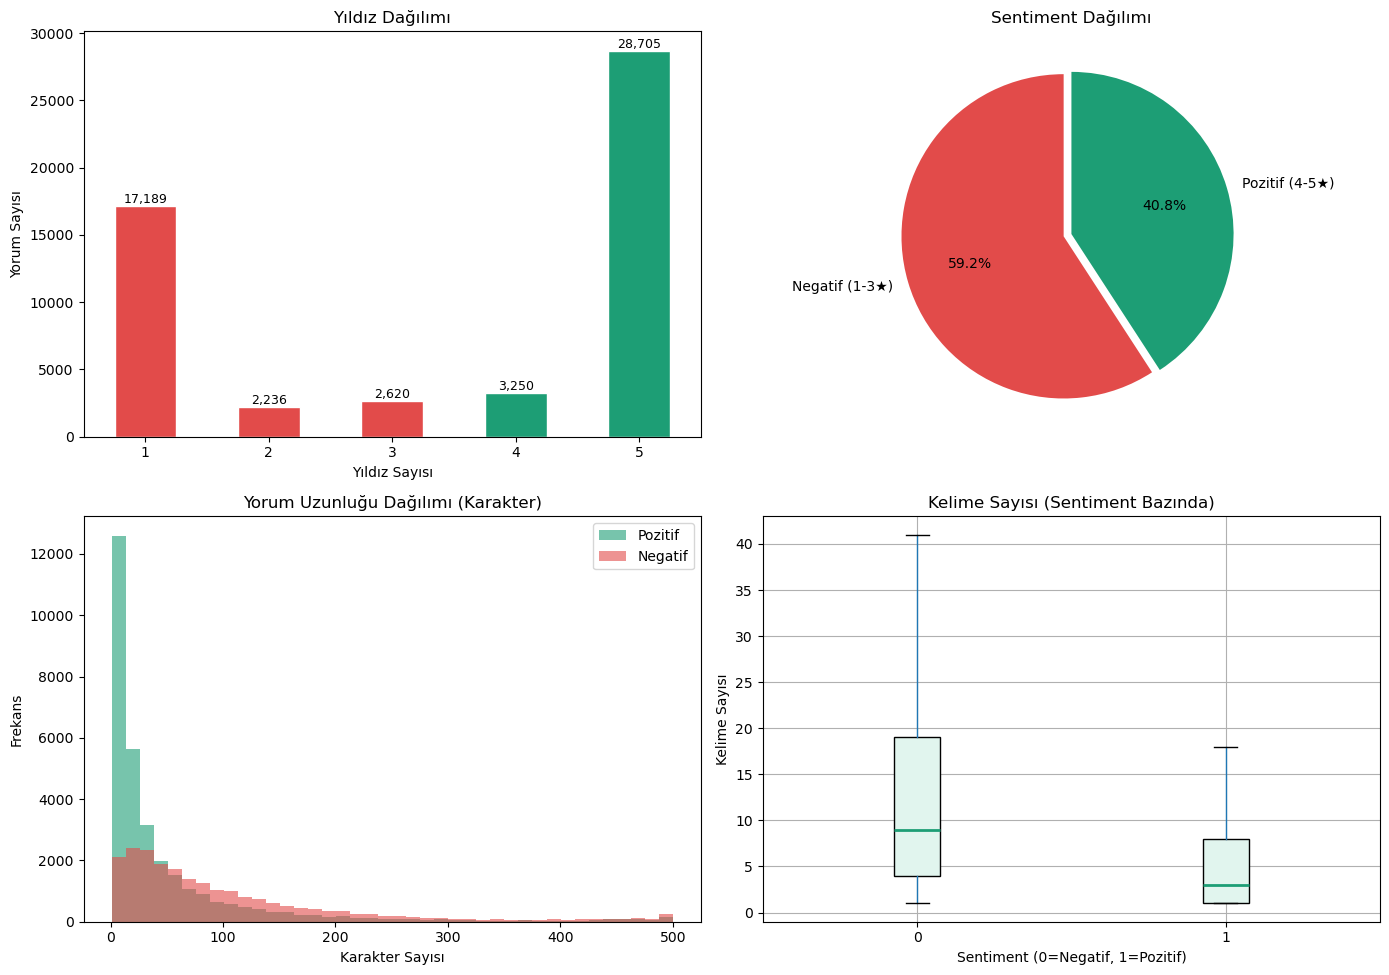

✓ Temel EDA görselleri kaydedildi.


In [5]:
# ── GÖRSEL 1-4: Temel EDA görselleri ───────────────────────────────────────
# Uzunluk özelliklerini hesapla (EDA için)
df['yorum_uzunlugu'] = df['text'].astype(str).apply(len)
df['kelime_sayisi']  = df['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Keşifsel Veri Analizi — Temel Dağılımlar', fontsize=16, fontweight='bold')

# Görsel 1: Rating dağılımı
ax1 = axes[0, 0]
df['rating'].value_counts().sort_index().plot(
    kind='bar', ax=ax1,
    color=['#E24B4A','#E24B4A','#E24B4A','#1D9E75','#1D9E75'],
    edgecolor='white'
)
ax1.set_title('Yıldız Dağılımı')
ax1.set_xlabel('Yıldız Sayısı')
ax1.set_ylabel('Yorum Sayısı')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}',
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom', fontsize=9)

# Görsel 2: Sentiment dağılımı (pasta)
ax2 = axes[0, 1]
label_counts = df['label'].value_counts()
wedges, texts, autotexts = ax2.pie(
    label_counts,
    labels=['Negatif (1-3★)', 'Pozitif (4-5★)'],
    autopct='%1.1f%%',
    colors=['#E24B4A', '#1D9E75'],
    startangle=90,
    explode=(0.05, 0)
)
ax2.set_title('Sentiment Dağılımı')

# Görsel 3: Yorum uzunluğu histogramı
ax3 = axes[1, 0]
df[df['label'] == 1]['yorum_uzunlugu'].clip(upper=500).plot(
    kind='hist', ax=ax3, alpha=0.6, color='#1D9E75', label='Pozitif', bins=40
)
df[df['label'] == 0]['yorum_uzunlugu'].clip(upper=500).plot(
    kind='hist', ax=ax3, alpha=0.6, color='#E24B4A', label='Negatif', bins=40
)
ax3.set_title('Yorum Uzunluğu Dağılımı (Karakter)')
ax3.set_xlabel('Karakter Sayısı')
ax3.set_ylabel('Frekans')
ax3.legend()

# Görsel 4: Kelime sayısı boxplot
ax4 = axes[1, 1]
df.boxplot(
    column='kelime_sayisi', by='label', ax=ax4,
    patch_artist=True,
    boxprops=dict(facecolor='#E1F5EE'),
    medianprops=dict(color='#1D9E75', linewidth=2),
    showfliers=False
)
ax4.set_title('Kelime Sayısı (Sentiment Bazında)')
ax4.set_xlabel('Sentiment (0=Negatif, 1=Pozitif)')
ax4.set_ylabel('Kelime Sayısı')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_temel.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Temel EDA görselleri kaydedildi.')

### 2.1 Uygulama Bazlı Analiz

Her uygulamadan gelen yorum sayısını ve pozitif/negatif dağılımını inceleyelim.

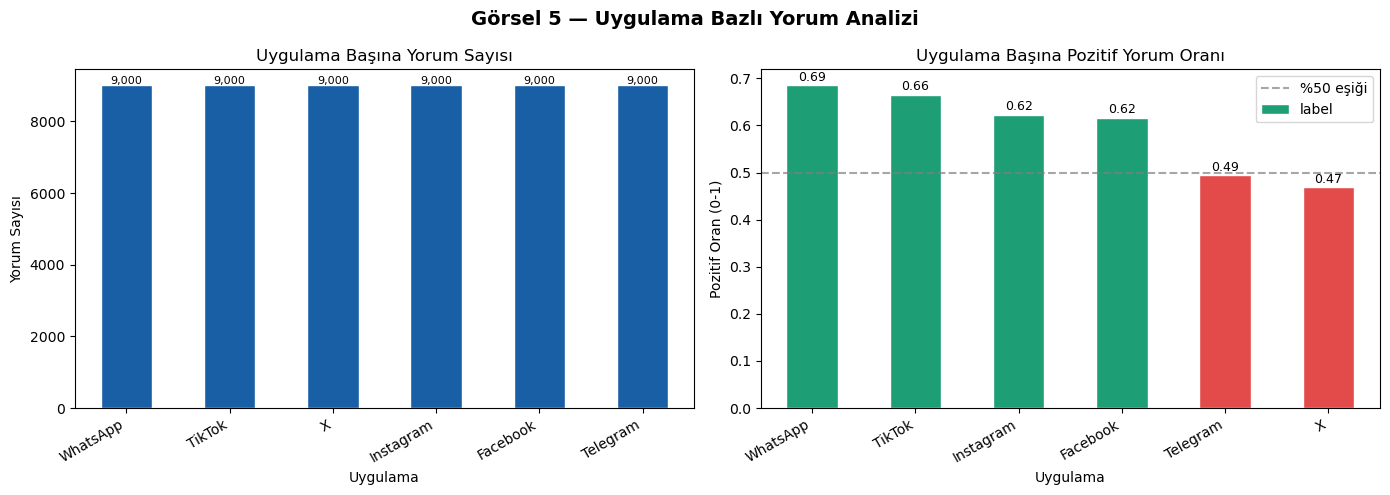


=== Uygulama Bazlı İstatistikler ===
           yorum_sayisi  pozitif_oran  ort_rating
app                                              
WhatsApp           9000         0.685       3.805
TikTok             9000         0.665       3.729
Instagram          9000         0.622       3.561
Facebook           9000         0.616       3.533
Telegram           9000         0.494       3.094
X                  9000         0.469       2.950


In [6]:
# ── GÖRSEL 5: Uygulama bazlı analiz ────────────────────────────────────────
if 'app' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Görsel 5 — Uygulama Bazlı Yorum Analizi', fontsize=14, fontweight='bold')

    # Uygulama başına yorum sayısı
    ax1 = axes[0]
    app_counts = df['app'].value_counts()
    bars = app_counts.plot(kind='bar', ax=ax1, color='#185FA5', edgecolor='white')
    ax1.set_title('Uygulama Başına Yorum Sayısı')
    ax1.set_xlabel('Uygulama')
    ax1.set_ylabel('Yorum Sayısı')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
    for p in ax1.patches:
        ax1.annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 50),
                     ha='center', fontsize=8)

    # Uygulama başına pozitif oran
    ax2 = axes[1]
    app_sentiment = df.groupby('app')['label'].mean().sort_values(ascending=False)
    renkler = ['#1D9E75' if x > 0.5 else '#E24B4A' for x in app_sentiment]
    app_sentiment.plot(kind='bar', ax=ax2, color=renkler, edgecolor='white')
    ax2.set_title('Uygulama Başına Pozitif Yorum Oranı')
    ax2.set_xlabel('Uygulama')
    ax2.set_ylabel('Pozitif Oran (0-1)')
    ax2.axhline(0.5, linestyle='--', color='gray', alpha=0.7, label='%50 eşiği')
    ax2.legend()
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')
    for p in ax2.patches:
        ax2.annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.01),
                     ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('eda_app_analizi.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n=== Uygulama Bazlı İstatistikler ===')
    print(df.groupby('app').agg(
        yorum_sayisi=('label', 'count'),
        pozitif_oran=('label', 'mean'),
        ort_rating=('rating', 'mean')
    ).round(3).sort_values('pozitif_oran', ascending=False))
else:
    print('⚠️  app sütunu bulunamadı (scraping tekrar yapılması gerekebilir).')

### 2.2 Korelasyon Matrisi

Sayısal özellikler arasındaki ilişkiyi inceleyelim.

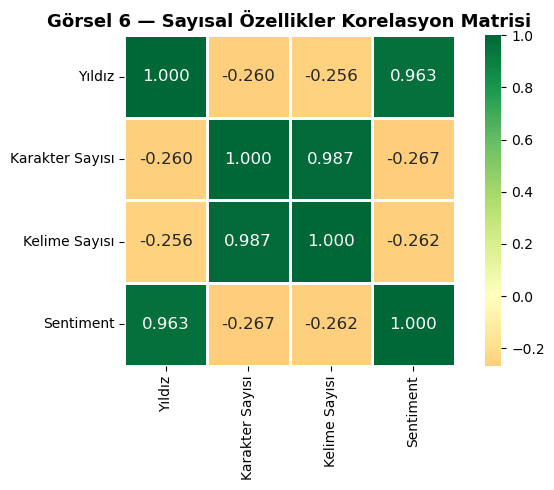

=== İçgörüler ===
Karakter sayısı ↔ Sentiment korelasyonu : -0.267
Kelime sayısı   ↔ Sentiment korelasyonu : -0.262
→ Uzun yorumlar daha çok negatif: Şikayet eden kullanıcılar daha ayrıntılı yazıyor.

=== Yorum Uzunluğu İstatistikleri (Sentiment Bazında) ===
      yorum_uzunlugu                                                 \
               count    mean     std  min   25%   50%    75%    max   
label                                                                 
0            22045.0  103.52  106.19  1.0  31.0  68.0  136.0  500.0   
1            31955.0   51.14   82.60  1.0   8.0  20.0   55.0  500.0   

      kelime_sayisi                                           
              count   mean    std  min  25%  50%   75%   max  
label                                                         
0           22045.0  14.29  14.40  1.0  4.0  9.0  19.0  99.0  
1           31955.0   7.38  11.04  1.0  1.0  3.0   8.0  95.0  


In [7]:
# ── GÖRSEL 6: Korelasyon Matrisi ────────────────────────────────────────────
korelasyon_df = df[['rating', 'yorum_uzunlugu', 'kelime_sayisi', 'label']].copy()
korelasyon_df.columns = ['Yıldız', 'Karakter Sayısı', 'Kelime Sayısı', 'Sentiment']

korelasyon_matrisi = korelasyon_df.corr()

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(korelasyon_matrisi, dtype=bool), k=1)
sns.heatmap(
    korelasyon_matrisi,
    annot=True, fmt='.3f', cmap='RdYlGn',
    center=0, square=True, linewidths=0.8,
    annot_kws={'size': 12}
)
plt.title('Görsel 6 — Sayısal Özellikler Korelasyon Matrisi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_korelasyon.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== İçgörüler ===')
kor_uzun  = korelasyon_matrisi.loc['Karakter Sayısı', 'Sentiment']
kor_kelime = korelasyon_matrisi.loc['Kelime Sayısı', 'Sentiment']
print(f'Karakter sayısı ↔ Sentiment korelasyonu : {kor_uzun:.3f}')
print(f'Kelime sayısı   ↔ Sentiment korelasyonu : {kor_kelime:.3f}')
if kor_uzun < 0:
    print('→ Uzun yorumlar daha çok negatif: Şikayet eden kullanıcılar daha ayrıntılı yazıyor.')
print()

# Uzunluk istatistikleri
print('=== Yorum Uzunluğu İstatistikleri (Sentiment Bazında) ===')
print(df.groupby('label')[['yorum_uzunlugu', 'kelime_sayisi']].describe().round(2))

---
## 3. Veri Önişleme

### 3.1 Metin Temizleme

**Strateji:**
- Eksik `text` değerleri silinir (düşük oran, doldurma anlamsız)
- URL, mention, hashtag, noktalama işaretleri kaldırılır
- Türkçe stopword listesi uygulanır
- Çok kısa token'lar (len ≤ 1) kaldırılır

In [8]:
# Türkçe stopwords
STOPWORDS_TR = {
    've','ile','bu','bir','çok','için','de','da','mi','mu','mü','mı',
    'ben','sen','o','biz','siz','onlar','ama','fakat','lakin','ya',
    'ki','ne','bu','şu','her','hiç','daha','en','gibi','kadar',
    'olan','olarak','var','yok','the','is','in','it','a','an','of','on',
    'ise','da','de','ki','mi','ne','bile','ya','hem','veya'
}


def temizle(text):
    """
    Ham metni temizler: küçük harf dönüşümü, URL/mention/hashtag kaldırma,
    noktalama temizleme, Türkçe stopword eleme.

    Args:
        text (str): Ham yorum metni

    Returns:
        str: Temizlenmiş metin
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)           # URL kaldır
    text = re.sub(r'@\w+|#\w+', '', text)                          # mention/hashtag
    text = re.sub(r'[^a-zA-Z0-9ğüşöçıİĞÜŞÖÇ\s]', ' ', text)       # noktalama
    text = re.sub(r'\s+', ' ', text).strip()                        # boşluk
    tokens = [t for t in text.split() if t not in STOPWORDS_TR and len(t) > 1]
    return ' '.join(tokens)


# Uygula
df = df.dropna(subset=['text']).reset_index(drop=True)
df['text_clean'] = df['text'].apply(temizle)
df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)

print(f'✓ Önişleme tamamlandı. Kalan yorum sayısı: {len(df):,}')
print()
print('--- Örnek Temizleme ---')
for i in range(3):
    print(f'  Ham   : {str(df["text"].iloc[i])[:80]}')
    print(f'  Temiz : {df["text_clean"].iloc[i][:80]}')
    print()

✓ Önişleme tamamlandı. Kalan yorum sayısı: 52,397

--- Örnek Temizleme ---
  Ham   : ya şu okundu sorununa bir çözüm bulun okundular ekrandan gitmiyor
  Temiz : okundu sorununa çözüm bulun okundular ekrandan gitmiyor

  Ham   : güzel
  Temiz : güzel

  Ham   : vatsap çok pis
  Temiz : vatsap pis



### 3.2 Özellik Mühendisliği (Bonus: +5 puan)

TF-IDF'e ek olarak metinden türetilen **sayısal özellikler** oluşturulmuştur.  
Bu özellikler metin içeriğinden bağımsız, davranışsal örüntüleri yakalamaktadır.

In [9]:
# ── HAM METİN üzerinden özellik çıkar (temizlemeden önce, orijinal metin kullanılır) ──
df['feat_kelime_sayisi']       = df['text'].astype(str).apply(lambda x: len(x.split()))
df['feat_karakter_sayisi']     = df['text'].astype(str).apply(len)
df['feat_ort_kelime_uzun']     = df['text'].astype(str).apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)
df['feat_buyuk_harf_orani']    = df['text'].astype(str).apply(
    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1)
)
df['feat_unlem_sayisi']        = df['text'].astype(str).str.count('!')
df['feat_soru_sayisi']         = df['text'].astype(str).str.count(r'\?')
df['feat_tekrar_harf']         = df['text'].astype(str).apply(
    lambda x: len(re.findall(r'(.)\1{2,}', x))    # ahhh, çokkk gibi tekrar harfler
)

# Uygulama one-hot encoding
if 'app' in df.columns:
    app_dummies = pd.get_dummies(df['app'], prefix='app', dtype=int)
    df = pd.concat([df, app_dummies], axis=1)
    APP_COLS = app_dummies.columns.tolist()
else:
    APP_COLS = []

BASE_NUMERIC_FEATS = [
    'feat_kelime_sayisi', 'feat_karakter_sayisi', 'feat_ort_kelime_uzun',
    'feat_buyuk_harf_orani', 'feat_unlem_sayisi', 'feat_soru_sayisi',
    'feat_tekrar_harf'
]
NUMERIC_FEATS = BASE_NUMERIC_FEATS + APP_COLS

print(f'✓ Özellik mühendisliği tamamlandı. Toplam sayısal özellik: {len(NUMERIC_FEATS)}')
print()
print('--- Özellik İstatistikleri (Sentiment Bazında) ---')
print(df.groupby('label')[BASE_NUMERIC_FEATS].mean().round(3))

✓ Özellik mühendisliği tamamlandı. Toplam sayısal özellik: 13

--- Özellik İstatistikleri (Sentiment Bazında) ---
       feat_kelime_sayisi  feat_karakter_sayisi  feat_ort_kelime_uzun  \
label                                                                   
0                  14.362               104.102                 6.386   
1                   7.666                53.334                 5.793   

       feat_buyuk_harf_orani  feat_unlem_sayisi  feat_soru_sayisi  \
label                                                               
0                      0.029              0.088             0.071   
1                      0.038              0.023             0.019   

       feat_tekrar_harf  
label                    
0                 0.081  
1                 0.086  


### 3.3 Eğitim / Doğrulama / Test Bölmesi

**Bölme oranı:** %70 / %15 / %15  
**Stratified split** kullanılmıştır: Sınıf dengesi tüm setlerde korunur.

**Validation setinin rolü:**  
- GridSearchCV/RandomizedSearchCV kendi içinde 5-fold CV ile model seçimi yapar  
- Dış validation seti → arama bittikten sonra her modelin ara performansını izlemek için kullanılır  
- Test seti → yalnızca nihai karşılaştırmada bir kez kullanılır

In [10]:
X_text = df['text_clean']
X_num  = df[NUMERIC_FEATS].values.astype(np.float32)
y      = df['label']

# Önce test setini ayır
X_text_tmp, X_text_test, X_num_tmp, X_num_test, y_tmp, y_test = train_test_split(
    X_text, X_num, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Kalan veriyi train / validation olarak böl
val_ratio = VALIDATION_SIZE / (1 - TEST_SIZE)
(X_text_train, X_text_val,
 X_num_train,  X_num_val,
 y_train,      y_val) = train_test_split(
    X_text_tmp, X_num_tmp, y_tmp,
    test_size=val_ratio,
    random_state=RANDOM_STATE,
    stratify=y_tmp
)

print(f'Train      : {len(X_text_train):,} örnek (%{len(X_text_train)/len(X_text)*100:.0f})')
print(f'Validation : {len(X_text_val):,} örnek (%{len(X_text_val)/len(X_text)*100:.0f})')
print(f'Test       : {len(X_text_test):,} örnek (%{len(X_text_test)/len(X_text)*100:.0f})')
print()
print(f'Train  — Pozitif oranı: %{y_train.mean()*100:.1f}')
print(f'Val    — Pozitif oranı: %{y_val.mean()*100:.1f}')
print(f'Test   — Pozitif oranı: %{y_test.mean()*100:.1f}')

Train      : 36,677 örnek (%70)
Validation : 7,860 örnek (%15)
Test       : 7,860 örnek (%15)

Train  — Pozitif oranı: %58.2
Val    — Pozitif oranı: %58.2
Test   — Pozitif oranı: %58.2


---
### 3.4 TF-IDF Öncesi ve Sonrası Veri Karşılaştırması

TF-IDF, ham metni modelin anlayabileceği sayısal bir matrise dönüştürür.  
Bu hücrede dönüşümün her adımını somut örneklerle karşılaştırıyoruz.

> ⚠️ **Data Leakage önlemi:** `TfidfVectorizer` yalnızca **train** setine `fit` edilmiş,  
> `transform` ise val ve test setine uygulanmıştır. Aşağıdaki istatistikler bunu doğrular.

╔══════════════════════════════════════════════════════════════╗
║          A) BOYUT KARŞILAŞTIRMASI                           ║
╚══════════════════════════════════════════════════════════════╝
  Ham metin (X_text_train) :  36,677 satır  →  her biri değişken uzunlukta string
  TF-IDF matris (train)    :  36,677 satır  ×  10,000 sütun (özellik)
  TF-IDF matris (val)      :   7,860 satır  ×  10,000 sütun
  TF-IDF matris (test)     :   7,860 satır  ×  10,000 sütun

  Öğrenilen kelime hazinesi (vocab)  : 10,000 token
  N-gram aralığı                     : (1, 2)
  Seyreklik (sparsity)               : %99.91
  Bellek (dense olsaydı)             : ~2.93 GB
  Bellek (seyrek matris, gerçek)     : ~2.6 MB

╔══════════════════════════════════════════════════════════════╗
║          B) ÖRNEK SATIR DÖNÜŞÜMÜ                           ║
╚══════════════════════════════════════════════════════════════╝
  Ham metin    : "güzel"
  Vektör boyutu: 10,000 boyutlu  →  1 sıfırdan farklı değer (geri kalan 0)


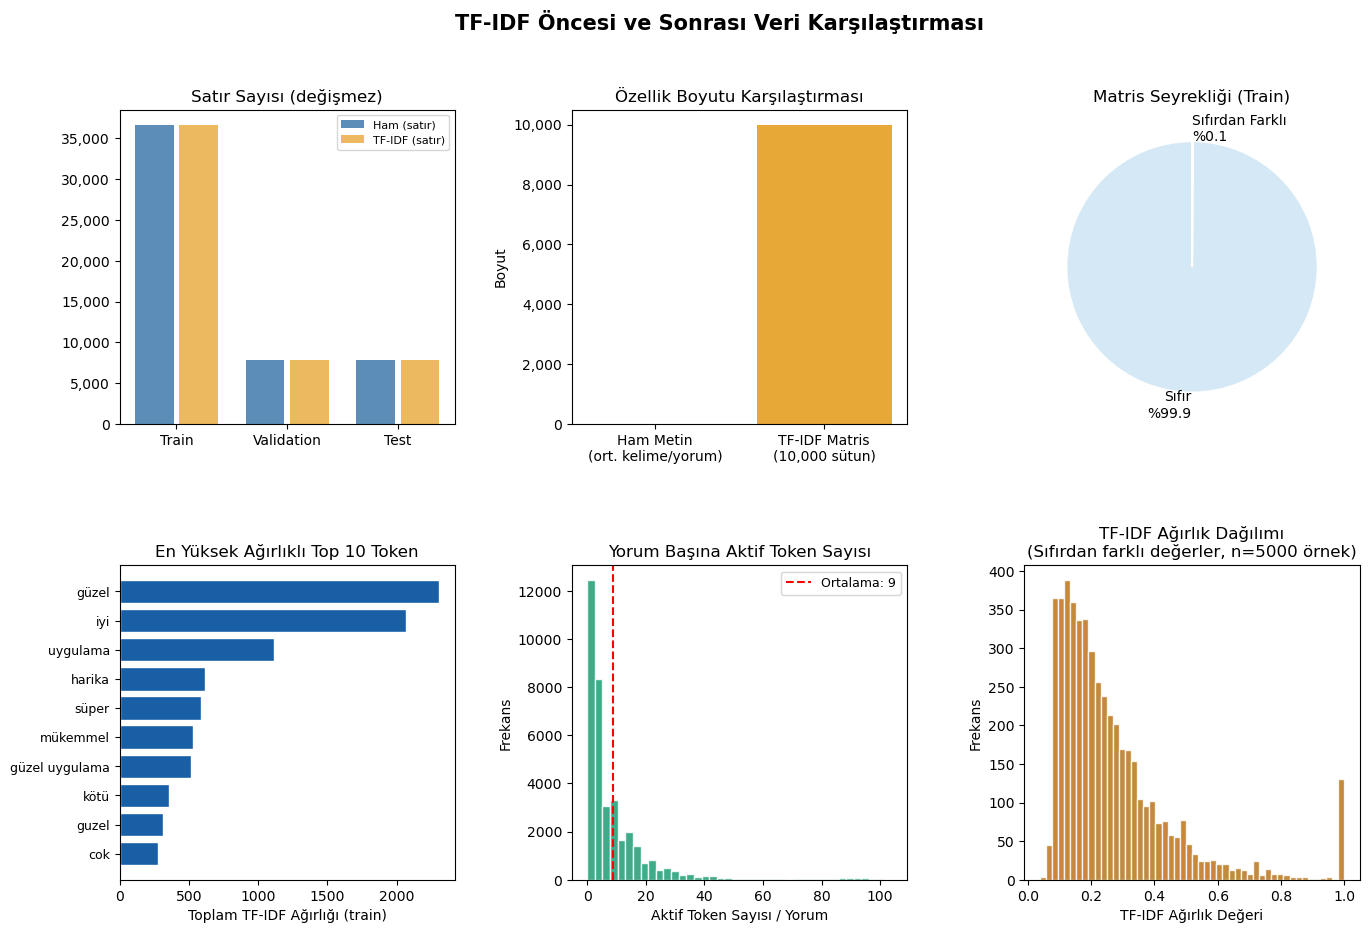

✓ TF-IDF karşılaştırma görseli kaydedildi: tfidf_karsilastirma.png


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Sadece eğitim setine fit et (data leakage önlemi) ────────────────────────
TFIDF_MAX_FEATURES = 10000  # 12k veri için optimize edildi
TFIDF_NGRAM        = (1, 2)

demo_tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=TFIDF_NGRAM)
X_train_tfidf = demo_tfidf.fit_transform(X_text_train)   # SADECE train'e fit
X_val_tfidf   = demo_tfidf.transform(X_text_val)         # sadece transform
X_test_tfidf  = demo_tfidf.transform(X_text_test)        # sadece transform

vocab = demo_tfidf.vocabulary_
feature_names = demo_tfidf.get_feature_names_out()

# ════════════════════════════════════════════════════════════════════════════
# BÖLÜM A — Boyut Karşılaştırması
# ════════════════════════════════════════════════════════════════════════════
print('╔══════════════════════════════════════════════════════════════╗')
print('║          A) BOYUT KARŞILAŞTIRMASI                           ║')
print('╚══════════════════════════════════════════════════════════════╝')
print(f'  Ham metin (X_text_train) : {len(X_text_train):>7,} satır  →  her biri değişken uzunlukta string')
print(f'  TF-IDF matris (train)    : {X_train_tfidf.shape[0]:>7,} satır  ×  {X_train_tfidf.shape[1]:>6,} sütun (özellik)')
print(f'  TF-IDF matris (val)      : {X_val_tfidf.shape[0]:>7,} satır  ×  {X_val_tfidf.shape[1]:>6,} sütun')
print(f'  TF-IDF matris (test)     : {X_test_tfidf.shape[0]:>7,} satır  ×  {X_test_tfidf.shape[1]:>6,} sütun')
print()
print(f'  Öğrenilen kelime hazinesi (vocab)  : {len(vocab):,} token')
print(f'  N-gram aralığı                     : {TFIDF_NGRAM}')
print(f'  Seyreklik (sparsity)               : %{(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1]))*100:.2f}')
print(f'  Bellek (dense olsaydı)             : ~{X_train_tfidf.shape[0]*X_train_tfidf.shape[1]*8/1e9:.2f} GB')
print(f'  Bellek (seyrek matris, gerçek)     : ~{X_train_tfidf.data.nbytes/1e6:.1f} MB')

# ════════════════════════════════════════════════════════════════════════════
# BÖLÜM B — Örnek Satır: Ham Metin → TF-IDF Vektörü
# ════════════════════════════════════════════════════════════════════════════
print()
print('╔══════════════════════════════════════════════════════════════╗')
print('║          B) ÖRNEK SATIR DÖNÜŞÜMÜ                           ║')
print('╚══════════════════════════════════════════════════════════════╝')
import numpy as np
ornek_idx   = 0
ornek_ham   = X_text_train.iloc[ornek_idx]
ornek_vec   = X_train_tfidf[ornek_idx]
sifirdan_farkli = ornek_vec.nnz
print(f'  Ham metin    : "{ornek_ham[:90]}"')
print(f'  Vektör boyutu: {ornek_vec.shape[1]:,} boyutlu  →  {sifirdan_farkli} sıfırdan farklı değer (geri kalan 0)')
print()
print('  En yüksek TF-IDF ağırlıklı tokenlar (bu yorum için):')
print(f'  {"Token":<22} {"TF-IDF Ağırlığı":>16}')
print('  ' + '-'*40)
dizi       = ornek_vec.toarray().flatten()
top_idx_s  = dizi.argsort()[::-1][:10]
for idx in top_idx_s:
    if dizi[idx] > 0:
        print(f'  {feature_names[idx]:<22} {dizi[idx]:>16.5f}')

# ════════════════════════════════════════════════════════════════════════════
# BÖLÜM C — Kelime Hazinesi Örnekleri
# ════════════════════════════════════════════════════════════════════════════
print()
print('╔══════════════════════════════════════════════════════════════╗')
print('║          C) KELİME HAZİNESİNDEN ÖRNEKLER                   ║')
print('╚══════════════════════════════════════════════════════════════╝')
import random
random.seed(RANDOM_STATE)
unigrams = [t for t in feature_names if ' ' not in t][:8]
bigrams  = [t for t in feature_names if ' ' in t][:8]
print(f'  Unigram örnekleri : {unigrams}')
print(f'  Bigram örnekleri  : {bigrams}')

# ════════════════════════════════════════════════════════════════════════════
# BÖLÜM D — Görsel Karşılaştırma
# ════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
fig.suptitle('TF-IDF Öncesi ve Sonrası Veri Karşılaştırması', fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# — Alt grafik 1: Train/Val/Test boyutları (öncesi vs sonrası) —
ax1 = fig.add_subplot(gs[0, 0])
setler  = ['Train', 'Validation', 'Test']
oncesi  = [len(X_text_train), len(X_text_val), len(X_text_test)]
sonrasi = [X_train_tfidf.shape[0], X_val_tfidf.shape[0], X_test_tfidf.shape[0]]
x = range(len(setler))
ax1.bar([i-0.2 for i in x], oncesi,  width=0.35, label='Ham (satır)', color='#5B8DB8')
ax1.bar([i+0.2 for i in x], sonrasi, width=0.35, label='TF-IDF (satır)', color='#E8A838', alpha=0.8)
ax1.set_xticks(list(x)); ax1.set_xticklabels(setler)
ax1.set_title('Satır Sayısı (değişmez)')
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))

# — Alt grafik 2: Sütun boyutu öncesi vs sonrası —
ax2 = fig.add_subplot(gs[0, 1])
avg_token = int(X_text_train.apply(lambda x: len(x.split())).mean())
ax2.bar(['Ham Metin\n(ort. kelime/yorum)', f'TF-IDF Matris\n({TFIDF_MAX_FEATURES:,} sütun)'],
        [avg_token, TFIDF_MAX_FEATURES], color=['#5B8DB8','#E8A838'])
ax2.set_title('Özellik Boyutu Karşılaştırması')
ax2.set_ylabel('Boyut')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))

# — Alt grafik 3: Seyreklik (sparsity) gösterimi —
ax3 = fig.add_subplot(gs[0, 2])
sparsity = (1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1]))*100
ax3.pie([sparsity, 100-sparsity],
        labels=[f'Sıfır\n%{sparsity:.1f}', f'Sıfırdan Farklı\n%{100-sparsity:.1f}'],
        colors=['#D5E8F5','#185FA5'], autopct='', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':1.5})
ax3.set_title('Matris Seyrekliği (Train)')

# — Alt grafik 4: En sık geçen tokenlar —
ax4 = fig.add_subplot(gs[1, 0])
import numpy as np
token_freqs = np.asarray(X_train_tfidf.sum(axis=0)).flatten()
top10_idx   = token_freqs.argsort()[::-1][:10]
ax4.barh(range(10), token_freqs[top10_idx][::-1], color='#185FA5', edgecolor='white')
ax4.set_yticks(range(10))
ax4.set_yticklabels(feature_names[top10_idx][::-1], fontsize=9)
ax4.set_xlabel('Toplam TF-IDF Ağırlığı (train)')
ax4.set_title('En Yüksek Ağırlıklı Top 10 Token')

# — Alt grafik 5: Yorum başına sıfırdan farklı token dağılımı —
ax5 = fig.add_subplot(gs[1, 1])
nnz_per_doc = np.diff(X_train_tfidf.indptr)  # her satırdaki nnz
ax5.hist(nnz_per_doc, bins=40, color='#1D9E75', edgecolor='white', alpha=0.85)
ax5.axvline(nnz_per_doc.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Ortalama: {nnz_per_doc.mean():.0f}')
ax5.set_xlabel('Aktif Token Sayısı / Yorum')
ax5.set_ylabel('Frekans')
ax5.set_title('Yorum Başına Aktif Token Sayısı')
ax5.legend(fontsize=9)

# — Alt grafik 6: TF-IDF ağırlık dağılımı —
ax6 = fig.add_subplot(gs[1, 2])
sample_vals = X_train_tfidf.data[:5000]  # sıfırdan farklı 5000 değer
ax6.hist(sample_vals, bins=50, color='#BA7517', edgecolor='white', alpha=0.85)
ax6.set_xlabel('TF-IDF Ağırlık Değeri')
ax6.set_ylabel('Frekans')
ax6.set_title('TF-IDF Ağırlık Dağılımı\n(Sıfırdan farklı değerler, n=5000 örnek)')

plt.savefig('tfidf_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ TF-IDF karşılaştırma görseli kaydedildi: tfidf_karsilastirma.png')

---
## 4. Model Eğitimi ve Hiperparametre Optimizasyonu

Her model için:
1. TF-IDF vektörizasyon + Model → **Pipeline** (data leakage önlenir, scaler sadece train'e fit edilir)
2. Default parametrelerle baseline sonuç
3. Hiperparametre arama uzayı tablosu
4. GridSearchCV / RandomizedSearchCV + **5-fold CV**
5. En iyi parametrelerle nihai model; validation + test değerlendirme

> ⚠️ **Data Leakage Önlemi:** `TfidfVectorizer` Pipeline içinde kullanıldığından,  
> `.fit()` yalnızca eğitim verisine uygulanır. `transform()` validation/test setine uygulanır.

In [12]:
# ── Sonuçları tutan sözlük ─────────────────────────────────────────────────
sonuclar = {}


def degerlendir(isim, model, X_tr, y_tr, X_val, y_val, X_te, y_te):
    """
    Modeli eğitir; validation ve test setlerinde değerlendirerek sonuçları depolar.

    Args:
        isim   (str)      : Model adı
        model             : scikit-learn Pipeline
        X_tr, y_tr        : Eğitim seti
        X_val, y_val      : Validation seti (ara kontrol)
        X_te, y_te        : Test seti (nihai değerlendirme)

    Returns:
        dict: Tüm metrikler
    """
    t0 = time.time()
    model.fit(X_tr, y_tr)
    sure = time.time() - t0

    # Test metrikleri
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc   = accuracy_score(y_te, y_pred)
    prec  = precision_score(y_te, y_pred, zero_division=0)
    rec   = recall_score(y_te, y_pred, zero_division=0)
    f1    = f1_score(y_te, y_pred, zero_division=0)

    # Validation metrikleri (arama sonrası ara kontrol)
    y_pred_val = model.predict(X_val)
    f1_val     = f1_score(y_val, y_pred_val, zero_division=0)
    acc_val    = accuracy_score(y_val, y_pred_val)

    sonuclar[isim] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'accuracy': acc,   'precision': prec,
        'recall':   rec,   'f1':        f1,
        'f1_val':   f1_val, 'acc_val':  acc_val,
        'sure':     sure
    }

    print(f'{isim:42s} | Test Acc: {acc:.4f}  F1: {f1:.4f}  Val F1: {f1_val:.4f}  Süre: {sure:.1f}s')
    return sonuclar[isim]


print('✓ Yardımcı fonksiyonlar hazır.')

✓ Yardımcı fonksiyonlar hazır.


### 4.1 Model 1: Logistic Regression (Baseline Doğrusal Model)

In [13]:
# ── Baseline — default parametreler ─────────────────────────────────────────
lr_baseline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('clf',   LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])
degerlendir('LR — Baseline', lr_baseline,
            X_text_train, y_train, X_text_val, y_val, X_text_test, y_test)

LR — Baseline                              | Test Acc: 0.8183  F1: 0.8432  Val F1: 0.8490  Süre: 0.7s


{'model': Pipeline(steps=[('tfidf',
                  TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                 ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
 'y_pred': array([0, 0, 1, ..., 1, 1, 0]),
 'y_prob': array([0.2593742 , 0.35511479, 0.60422704, ..., 0.70043369, 0.60422704,
        0.39925521]),
 'accuracy': 0.8183206106870229,
 'precision': 0.8475286849073257,
 'recall': 0.8390126692878986,
 'f1': 0.8432491767288693,
 'f1_val': 0.8489571899012075,
 'acc_val': 0.8249363867684478,
 'sure': 0.6598327159881592}

In [14]:
# ── Hiperparametre Arama Uzayı Tablosu ───────────────────────────────────────
lr_param_grid = {
    'tfidf__max_features': [8000, 10000],
    'tfidf__ngram_range':  [(1, 1), (1, 2)],
    'clf__C':              [0.1, 1.0, 10.0],
}

lr_hp_tablo = pd.DataFrame([
    {'Parametre': 'tfidf__max_features', 'Arama Aralığı': '[8000, 10000]',
     'Açıklama': 'TF-IDF vokabüler büyüklüğü'},
    {'Parametre': 'tfidf__ngram_range',  'Arama Aralığı': '(1,1) / (1,2)',
     'Açıklama': 'Unigram veya bigram'},
    {'Parametre': 'clf__C',              'Arama Aralığı': '[0.1, 1.0, 10.0]',
     'Açıklama': 'Regularization kuvveti — küçük C = güçlü regularization'},
])
print('=== LR — Hiperparametre Arama Uzayı ===')
print(lr_hp_tablo.to_string(index=False))
print(f'\nToplam kombinasyon: {2*2*3} = 12 (GridSearchCV × 5-fold = 60 fit)')

=== LR — Hiperparametre Arama Uzayı ===
          Parametre    Arama Aralığı                                                Açıklama
tfidf__max_features    [8000, 10000]                              TF-IDF vokabüler büyüklüğü
 tfidf__ngram_range    (1,1) / (1,2)                                     Unigram veya bigram
             clf__C [0.1, 1.0, 10.0] Regularization kuvveti — küçük C = güçlü regularization

Toplam kombinasyon: 12 = 12 (GridSearchCV × 5-fold = 60 fit)


In [15]:
# ── GridSearchCV ─────────────────────────────────────────────────────────────
lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lr_grid = GridSearchCV(
    lr_pipe, lr_param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
lr_grid.fit(X_text_train, y_train)

print(f'\nEn iyi parametreler : {lr_grid.best_params_}')
print(f'CV F1 skoru (train) : {lr_grid.best_score_:.4f}')

degerlendir('LR — Tuned', lr_grid.best_estimator_,
            X_text_train, y_train, X_text_val, y_val, X_text_test, y_test)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

En iyi parametreler : {'clf__C': 1.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
CV F1 skoru (train) : 0.8448
LR — Tuned                                 | Test Acc: 0.8183  F1: 0.8432  Val F1: 0.8490  Süre: 0.7s


{'model': Pipeline(steps=[('tfidf',
                  TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                 ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
 'y_pred': array([0, 0, 1, ..., 1, 1, 0]),
 'y_prob': array([0.2593742 , 0.35511479, 0.60422704, ..., 0.70043369, 0.60422704,
        0.39925521]),
 'accuracy': 0.8183206106870229,
 'precision': 0.8475286849073257,
 'recall': 0.8390126692878986,
 'f1': 0.8432491767288693,
 'f1_val': 0.8489571899012075,
 'acc_val': 0.8249363867684478,
 'sure': 0.6663551330566406}

### 4.2 Model 2: Random Forest (Ensemble — Ağaç Tabanlı)

In [16]:
# ── Baseline ─────────────────────────────────────────────────────────────────
rf_baseline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('clf',   RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])
degerlendir('RF — Baseline', rf_baseline,
            X_text_train, y_train, X_text_val, y_val, X_text_test, y_test)

RF — Baseline                              | Test Acc: 0.8106  F1: 0.8323  Val F1: 0.8299  Süre: 3.5s


{'model': Pipeline(steps=[('tfidf',
                  TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                 ('clf', RandomForestClassifier(n_jobs=-1, random_state=42))]),
 'y_pred': array([0, 0, 1, ..., 1, 1, 0]),
 'y_prob': array([0.175     , 0.4401559 , 0.76865796, ..., 0.73658537, 0.76865796,
        0.17727412]),
 'accuracy': 0.8105597964376591,
 'precision': 0.8591025342943501,
 'recall': 0.8071210135430319,
 'f1': 0.8323009347899538,
 'f1_val': 0.829913667451508,
 'acc_val': 0.8069974554707379,
 'sure': 3.476796865463257}

In [17]:
# ── Hiperparametre Arama Uzayı Tablosu ───────────────────────────────────────
rf_param_dist = {
    'tfidf__max_features':    [8000, 10000],
    'tfidf__ngram_range':     [(1, 1), (1, 2)],
    'clf__n_estimators':      [100, 200],
    'clf__max_depth':         [None, 20],
    'clf__min_samples_split': [2, 5],
}

rf_hp_tablo = pd.DataFrame([
    {'Parametre': 'tfidf__max_features',   'Arama Aralığı': '[8000, 10000]',
     'Açıklama': 'TF-IDF vokabüler büyüklüğü'},
    {'Parametre': 'tfidf__ngram_range',    'Arama Aralığı': '(1,1) / (1,2)',
     'Açıklama': 'N-gram aralığı'},
    {'Parametre': 'clf__n_estimators',     'Arama Aralığı': '[100, 200]',
     'Açıklama': 'Ağaç sayısı — artıkça performans artar, süre uzar'},
    {'Parametre': 'clf__max_depth',        'Arama Aralığı': '[None, 20]',
     'Açıklama': 'Maksimum derinlik — None = tam büyütme'},
    {'Parametre': 'clf__min_samples_split','Arama Aralığı': '[2, 5]',
     'Açıklama': 'Dal bölmesi için minimum örnek'},
])
print('=== RF — Hiperparametre Arama Uzayı ===')
print(rf_hp_tablo.to_string(index=False))
print(f'\nRandomizedSearchCV: n_iter=10, 5-fold CV → 50 fit')

=== RF — Hiperparametre Arama Uzayı ===
             Parametre Arama Aralığı                                          Açıklama
   tfidf__max_features [8000, 10000]                        TF-IDF vokabüler büyüklüğü
    tfidf__ngram_range (1,1) / (1,2)                                    N-gram aralığı
     clf__n_estimators    [100, 200] Ağaç sayısı — artıkça performans artar, süre uzar
        clf__max_depth    [None, 20]            Maksimum derinlik — None = tam büyütme
clf__min_samples_split        [2, 5]                    Dal bölmesi için minimum örnek

RandomizedSearchCV: n_iter=10, 5-fold CV → 50 fit


In [18]:
# ── RandomizedSearchCV ───────────────────────────────────────────────────────
rf_pipe = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist,
    n_iter=10, cv=5, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
rf_search.fit(X_text_train, y_train)

print(f'En iyi parametreler : {rf_search.best_params_}')
print(f'CV F1 skoru (train) : {rf_search.best_score_:.4f}')

degerlendir('RF — Tuned', rf_search.best_estimator_,
            X_text_train, y_train, X_text_val, y_val, X_text_test, y_test)

En iyi parametreler : {'tfidf__ngram_range': (1, 2), 'tfidf__max_features': 8000, 'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__max_depth': None}
CV F1 skoru (train) : 0.8310
RF — Tuned                                 | Test Acc: 0.8102  F1: 0.8313  Val F1: 0.8323  Süre: 2.6s


{'model': Pipeline(steps=[('tfidf',
                  TfidfVectorizer(max_features=8000, ngram_range=(1, 2))),
                 ('clf',
                  RandomForestClassifier(min_samples_split=5, n_jobs=-1,
                                         random_state=42))]),
 'y_pred': array([0, 0, 1, ..., 1, 1, 0]),
 'y_prob': array([0.4087619 , 0.41187081, 0.77182921, ..., 0.76814286, 0.77182921,
        0.17401805]),
 'accuracy': 0.8101781170483461,
 'precision': 0.8615276476101218,
 'recall': 0.8031891655744867,
 'f1': 0.8313361971512548,
 'f1_val': 0.8323218700831647,
 'acc_val': 0.8101781170483461,
 'sure': 2.5798468589782715}

### 4.3 Model 3: XGBoost (Gradient Boosting — Ağaç Tabanlı)

In [19]:
# ── Baseline ─────────────────────────────────────────────────────────────────
xgb_baseline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('clf',   XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0))
])
degerlendir('XGB — Baseline', xgb_baseline,
            X_text_train, y_train, X_text_val, y_val, X_text_test, y_test)

XGB — Baseline                             | Test Acc: 0.8014  F1: 0.8341  Val F1: 0.8370  Süre: 3.0s


{'model': Pipeline(steps=[('tfidf',
                  TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                 ('clf',
                  XGBClassifier(base_score=None, booster=None, callbacks=None,
                                colsample_bylevel=None, colsample_bynode=None,
                                colsample_bytree=None, device=None,
                                early_stopping_rounds=None,
                                enable_categorical=False, eval_metric='logloss',
                                feature_types=None, feature_weights=None,
                                gamma=None, grow_policy=None,
                                importance_type=None,
                                interaction_constraints=None, learning_rate=None,
                                max_bin=None, max_cat_threshold=None,
                                max_cat_to_onehot=None, max_delta_step=None,
                                max_depth=None, max_leaves=None,
            

In [20]:
# ── Hiperparametre Arama Uzayı Tablosu ───────────────────────────────────────
xgb_param_dist = {
    'tfidf__max_features': [8000, 10000],
    'clf__n_estimators':   [100, 200],
    'clf__max_depth':      [3, 5],
    'clf__learning_rate':  [0.1, 0.2],
    'clf__subsample':      [0.8, 1.0],
}

xgb_hp_tablo = pd.DataFrame([
    {'Parametre': 'tfidf__max_features', 'Arama Aralığı': '[8000, 10000]',
     'Açıklama': 'TF-IDF vokabüler büyüklüğü'},
    {'Parametre': 'clf__n_estimators',   'Arama Aralığı': '[100, 200]',
     'Açıklama': 'Boosting tur sayısı'},
    {'Parametre': 'clf__max_depth',      'Arama Aralığı': '[3, 5]',
     'Açıklama': 'Ağaç derinliği — düşük = az overfitting'},
    {'Parametre': 'clf__learning_rate',  'Arama Aralığı': '[0.1, 0.2]',
     'Açıklama': 'Öğrenme hızı (eta)'},
    {'Parametre': 'clf__subsample',      'Arama Aralığı': '[0.8, 1.0]',
     'Açıklama': 'Her boosting turunda kullanılan örnek oranı'},
])
print('=== XGBoost — Hiperparametre Arama Uzayı ===')
print(xgb_hp_tablo.to_string(index=False))
print(f'\nRandomizedSearchCV: n_iter=12, 5-fold CV → 60 fit')

=== XGBoost — Hiperparametre Arama Uzayı ===
          Parametre Arama Aralığı                                    Açıklama
tfidf__max_features [8000, 10000]                  TF-IDF vokabüler büyüklüğü
  clf__n_estimators    [100, 200]                         Boosting tur sayısı
     clf__max_depth        [3, 5]     Ağaç derinliği — düşük = az overfitting
 clf__learning_rate    [0.1, 0.2]                          Öğrenme hızı (eta)
     clf__subsample    [0.8, 1.0] Her boosting turunda kullanılan örnek oranı

RandomizedSearchCV: n_iter=12, 5-fold CV → 60 fit


In [21]:
# ── RandomizedSearchCV ───────────────────────────────────────────────────────
xgb_pipe = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0))
])

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_param_dist,
    n_iter=12, cv=5, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
xgb_search.fit(X_text_train, y_train)

print(f'En iyi parametreler : {xgb_search.best_params_}')
print(f'CV F1 skoru (train) : {xgb_search.best_score_:.4f}')

degerlendir('XGB — Tuned', xgb_search.best_estimator_,
            X_text_train, y_train, X_text_val, y_val, X_text_test, y_test)

En iyi parametreler : {'tfidf__max_features': 8000, 'clf__subsample': 1.0, 'clf__n_estimators': 200, 'clf__max_depth': 5, 'clf__learning_rate': 0.2}
CV F1 skoru (train) : 0.8350
XGB — Tuned                                | Test Acc: 0.8031  F1: 0.8349  Val F1: 0.8371  Süre: 3.2s


{'model': Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=8000)),
                 ('clf',
                  XGBClassifier(base_score=None, booster=None, callbacks=None,
                                colsample_bylevel=None, colsample_bynode=None,
                                colsample_bytree=None, device=None,
                                early_stopping_rounds=None,
                                enable_categorical=False, eval_metric='logloss',
                                feature_types=None, feature_weights=None,
                                gamma=None, grow_policy=None,
                                importance_type=None,
                                interaction_constraints=None, learning_rate=0.2,
                                max_bin=None, max_cat_threshold=None,
                                max_cat_to_onehot=None, max_delta_step=None,
                                max_depth=5, max_leaves=None,
                                min_child_weight=None, 

### 4.4 Model 4: LightGBM (Ek Boosting Modeli)

LightGBM, XGBoost'a alternatif bir gradient boosting kütüphanesidir.  
Özellikle büyük veri setlerinde XGBoost'tan daha hızlı eğitim sağlar.

In [22]:
# ── LightGBM Baseline ────────────────────────────────────────────────────────
lgb_baseline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('clf',   lgb.LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1))
])
degerlendir('LGB — Baseline', lgb_baseline,
            X_text_train, y_train, X_text_val, y_val, X_text_test, y_test)

LGB — Baseline                             | Test Acc: 0.8060  F1: 0.8372  Val F1: 0.8405  Süre: 1.2s


{'model': Pipeline(steps=[('tfidf',
                  TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                 ('clf', LGBMClassifier(random_state=42, verbosity=-1))]),
 'y_pred': array([0, 1, 1, ..., 1, 1, 0]),
 'y_prob': array([0.27129368, 0.57380435, 0.57380435, ..., 0.54743375, 0.57380435,
        0.45442972]),
 'accuracy': 0.8059796437659033,
 'precision': 0.8188844787967412,
 'recall': 0.8562691131498471,
 'f1': 0.8371596369460759,
 'f1_val': 0.8405177024280672,
 'acc_val': 0.8103053435114503,
 'sure': 1.2491488456726074}

In [23]:
# ── LightGBM RandomizedSearchCV ──────────────────────────────────────────────
lgb_param_dist = {
    'tfidf__max_features': [8000, 10000],
    'clf__n_estimators':   [100, 200],
    'clf__max_depth':      [5, -1],
    'clf__learning_rate':  [0.1, 0.2],
    'clf__num_leaves':     [31, 63],
}

lgb_pipe = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   lgb.LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1))
])

lgb_search = RandomizedSearchCV(
    lgb_pipe, lgb_param_dist,
    n_iter=10, cv=5, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
lgb_search.fit(X_text_train, y_train)

print(f'En iyi parametreler : {lgb_search.best_params_}')
print(f'CV F1 skoru (train) : {lgb_search.best_score_:.4f}')

degerlendir('LGB — Tuned', lgb_search.best_estimator_,
            X_text_train, y_train, X_text_val, y_val, X_text_test, y_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

En iyi parametreler : {'tfidf__max_features': 10000, 'clf__num_leaves': 31, 'clf__n_estimators': 100, 'clf__max_depth': -1, 'clf__learning_rate': 0.2}
CV F1 skoru (train) : 0.8385
LGB — Tuned                                | Test Acc: 0.8115  F1: 0.8403  Val F1: 0.8401  Süre: 0.8s


{'model': Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=10000)),
                 ('clf',
                  LGBMClassifier(learning_rate=0.2, random_state=42,
                                 verbosity=-1))]),
 'y_pred': array([0, 1, 1, ..., 1, 1, 0]),
 'y_prob': array([0.18816719, 0.5665792 , 0.6017802 , ..., 0.6017802 , 0.6017802 ,
        0.43165457]),
 'accuracy': 0.8114503816793893,
 'precision': 0.8293617021276596,
 'recall': 0.8514635211882918,
 'f1': 0.8402672989868506,
 'f1_val': 0.8400862068965518,
 'acc_val': 0.8111959287531807,
 'sure': 0.7675302028656006}

---
## 5. Model Karşılaştırma ve Değerlendirme

In [24]:
# ── Kapsamlı Karşılaştırma Tablosu ──────────────────────────────────────────
satirlar = []
for isim, v in sonuclar.items():
    satirlar.append({
        'Model':      isim,
        'Accuracy':   round(v['accuracy'],  4),
        'Precision':  round(v['precision'], 4),
        'Recall':     round(v['recall'],    4),
        'F1 (Test)':  round(v['f1'],        4),
        'F1 (Val)':   round(v['f1_val'],    4),
        'Süre (s)':   round(v['sure'],      1),
    })

tablo = pd.DataFrame(satirlar)

# En iyi F1 satırını işaretle
best_idx = tablo['F1 (Test)'].idxmax()

print('=' * 85)
print('                     MODEL KARŞILAŞTIRMA TABLOSU')
print('=' * 85)
print(tablo.to_string(index=False))
print('=' * 85)
print(f'\n🏆 En iyi model: {tablo.loc[best_idx, "Model"]}  (F1={tablo.loc[best_idx, "F1 (Test)"]:.4f})')

                     MODEL KARŞILAŞTIRMA TABLOSU
         Model  Accuracy  Precision  Recall  F1 (Test)  F1 (Val)  Süre (s)
 LR — Baseline    0.8183     0.8475  0.8390     0.8432    0.8490       0.7
    LR — Tuned    0.8183     0.8475  0.8390     0.8432    0.8490       0.7
 RF — Baseline    0.8106     0.8591  0.8071     0.8323    0.8299       3.5
    RF — Tuned    0.8102     0.8615  0.8032     0.8313    0.8323       2.6
XGB — Baseline    0.8014     0.8124  0.8569     0.8341    0.8370       3.0
   XGB — Tuned    0.8031     0.8158  0.8550     0.8349    0.8371       3.2
LGB — Baseline    0.8060     0.8189  0.8563     0.8372    0.8405       1.2
   LGB — Tuned    0.8115     0.8294  0.8515     0.8403    0.8401       0.8

🏆 En iyi model: LR — Baseline  (F1=0.8432)


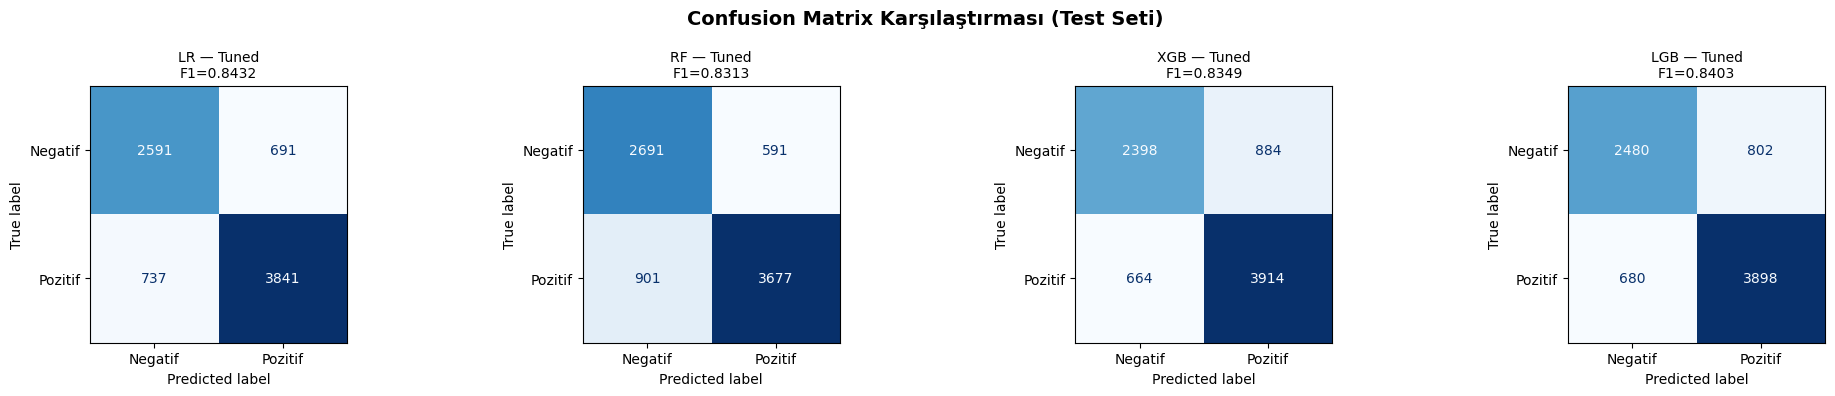

In [25]:
# ── Confusion Matrix — Tuned modeller ───────────────────────────────────────
tuned_modeller = [k for k in sonuclar if 'Tuned' in k]
ncols = len(tuned_modeller)
fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
if ncols == 1:
    axes = [axes]
fig.suptitle('Confusion Matrix Karşılaştırması (Test Seti)', fontsize=14, fontweight='bold')

for ax, isim in zip(axes, tuned_modeller):
    cm = confusion_matrix(y_test, sonuclar[isim]['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negatif', 'Pozitif'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{isim}\nF1={sonuclar[isim]["f1"]:.4f}', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

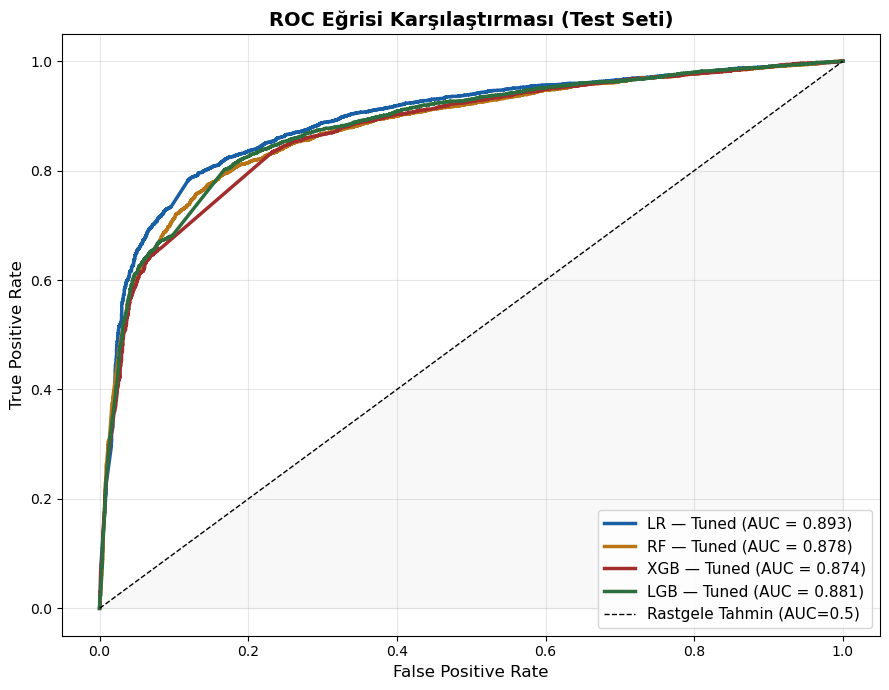

In [26]:
# ── ROC Eğrisi Karşılaştırması ───────────────────────────────────────────────
plt.figure(figsize=(9, 7))
renkler = {
    'LR — Tuned':  '#185FA5',
    'RF — Tuned':  '#BA7517',
    'XGB — Tuned': '#A32D2D',
    'LGB — Tuned': '#2D6E3E',
}

for isim in tuned_modeller:
    fpr, tpr, _ = roc_curve(y_test, sonuclar[isim]['y_prob'])
    roc_auc     = auc(fpr, tpr)
    renk        = renkler.get(isim, '#555555')
    plt.plot(fpr, tpr, label=f'{isim} (AUC = {roc_auc:.3f})', color=renk, linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Rastgele Tahmin (AUC=0.5)')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Eğrisi Karşılaştırması (Test Seti)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

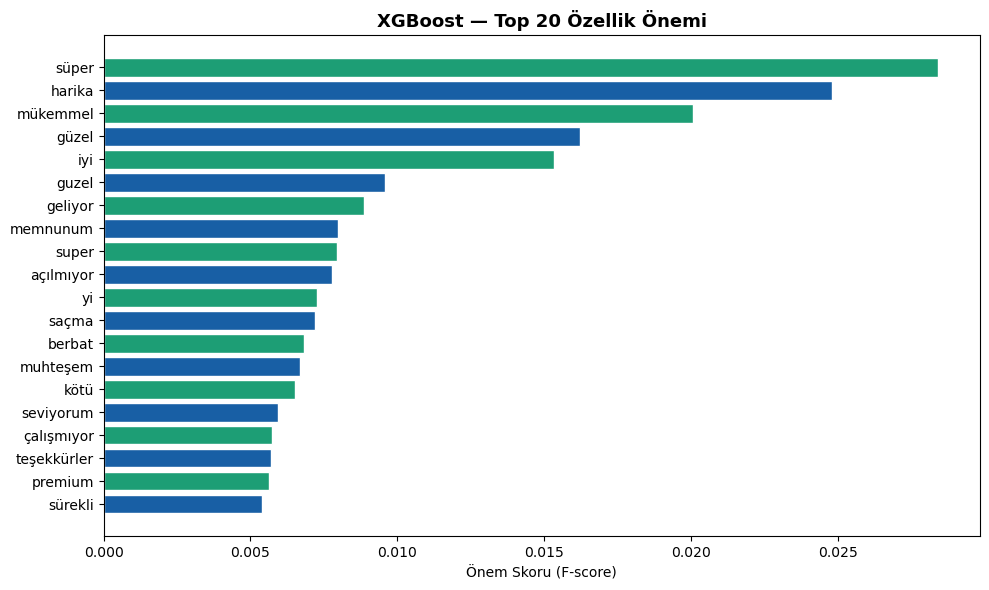


=== En Önemli 10 Özellik ===
  süper                : 0.02843
  harika               : 0.02482
  mükemmel             : 0.02008
  güzel                : 0.01622
  iyi                  : 0.01533
  guzel                : 0.00957
  geliyor              : 0.00886
  memnunum             : 0.00798
  super                : 0.00796
  açılmıyor            : 0.00779


In [27]:
# ── Feature Importance — XGBoost ─────────────────────────────────────────────
xgb_best_pipe    = sonuclar['XGB — Tuned']['model']
tfidf_vect       = xgb_best_pipe.named_steps['tfidf']
xgb_clf          = xgb_best_pipe.named_steps['clf']

feature_names    = tfidf_vect.get_feature_names_out()
importances      = xgb_clf.feature_importances_
top_idx          = importances.argsort()[::-1][:TOP_N_FEATURES]
top_features     = feature_names[top_idx]
top_importances  = importances[top_idx]

plt.figure(figsize=(10, 6))
colors = ['#1D9E75' if i % 2 == 0 else '#185FA5' for i in range(TOP_N_FEATURES)]
plt.barh(range(TOP_N_FEATURES), top_importances[::-1], color=colors[::-1], edgecolor='white')
plt.yticks(range(TOP_N_FEATURES), top_features[::-1])
plt.xlabel('Önem Skoru (F-score)')
plt.title(f'XGBoost — Top {TOP_N_FEATURES} Özellik Önemi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== En Önemli 10 Özellik ===')
for feat, imp in zip(top_features[:10], top_importances[:10]):
    print(f'  {feat:20s} : {imp:.5f}')

### 5.1 SHAP Açıklanabilirlik Analizi (Bonus: +5 puan)

SHAP (SHapley Additive exPlanations), her özelliğin tahmin kararına ne kadar katkıda bulunduğunu açıklar.  
- **Kırmızı bar** → o özellik pozitif sınıf tahminini artırıyor  
- **Mavi bar** → o özellik negatif sınıf tahminini artırıyor

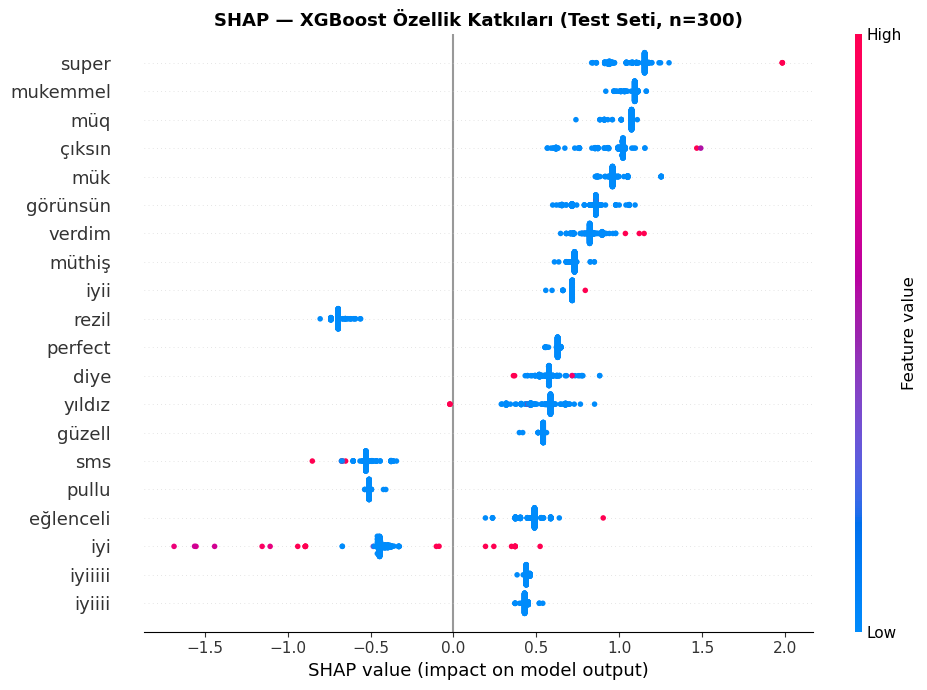

✓ SHAP analizi tamamlandı.


In [28]:
import shap

# XGBoost için TreeExplainer (en hızlı ve doğru SHAP yöntemi)
xgb_clf_shap   = sonuclar['XGB — Tuned']['model'].named_steps['clf']
tfidf_shap     = sonuclar['XGB — Tuned']['model'].named_steps['tfidf']

# Test verisinin bir alt kümesini dönüştür (bellek tasarrufu)
N_SHAP_SAMPLES  = 300
X_test_sparse   = tfidf_shap.transform(X_text_test[:N_SHAP_SAMPLES])
X_test_array    = X_test_sparse.toarray()
feature_names_s = tfidf_shap.get_feature_names_out()

explainer    = shap.TreeExplainer(xgb_clf_shap)
shap_values  = explainer.shap_values(X_test_array)

# SHAP Summary Plot
plt.figure()
shap.summary_plot(
    shap_values, X_test_array,
    feature_names=feature_names_s,
    max_display=20,
    show=False,
    plot_size=(10, 7)
)
plt.title('SHAP — XGBoost Özellik Katkıları (Test Seti, n=300)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ SHAP analizi tamamlandı.')

---
## 6. Sonuç ve Tartışma

In [29]:
# ── Nihai Özet ───────────────────────────────────────────────────────────────
tuned_sonuclar = {k: v for k, v in sonuclar.items() if 'Tuned' in k}
en_iyi_isim   = max(tuned_sonuclar, key=lambda k: sonuclar[k]['f1'])
en_iyi        = sonuclar[en_iyi_isim]

print('╔══════════════════════════════════════════════════════╗')
print('║              PROJE SONUÇ ÖZETİ                      ║')
print('╚══════════════════════════════════════════════════════╝')
print(f'\n🏆 En iyi model : {en_iyi_isim}')
print(f'   Accuracy     : {en_iyi["accuracy"]:.4f}')
print(f'   F1 Score     : {en_iyi["f1"]:.4f}')
print(f'   Precision    : {en_iyi["precision"]:.4f}')
print(f'   Recall       : {en_iyi["recall"]:.4f}')

print('\n=== Hiperparametre Optimizasyonunun Etkisi ===')
for model_adi in ['LR', 'RF', 'XGB', 'LGB']:
    base_key  = f'{model_adi} — Baseline'
    tuned_key = f'{model_adi} — Tuned'
    if base_key in sonuclar and tuned_key in sonuclar:
        base_f1  = sonuclar[base_key]['f1']
        tuned_f1 = sonuclar[tuned_key]['f1']
        fark     = (tuned_f1 - base_f1) * 100
        ok       = '▲' if fark > 0 else '▼'
        print(f'  {model_adi}: Baseline F1={base_f1:.4f} → Tuned F1={tuned_f1:.4f}  ({ok} {abs(fark):.2f} puan)')

print()
print(classification_report(
    y_test, sonuclar[en_iyi_isim]['y_pred'],
    target_names=['Negatif', 'Pozitif']
))

╔══════════════════════════════════════════════════════╗
║              PROJE SONUÇ ÖZETİ                      ║
╚══════════════════════════════════════════════════════╝

🏆 En iyi model : LR — Tuned
   Accuracy     : 0.8183
   F1 Score     : 0.8432
   Precision    : 0.8475
   Recall       : 0.8390

=== Hiperparametre Optimizasyonunun Etkisi ===
  LR: Baseline F1=0.8432 → Tuned F1=0.8432  (▼ 0.00 puan)
  RF: Baseline F1=0.8323 → Tuned F1=0.8313  (▼ 0.10 puan)
  XGB: Baseline F1=0.8341 → Tuned F1=0.8349  (▲ 0.08 puan)
  LGB: Baseline F1=0.8372 → Tuned F1=0.8403  (▲ 0.31 puan)

              precision    recall  f1-score   support

     Negatif       0.78      0.79      0.78      3282
     Pozitif       0.85      0.84      0.84      4578

    accuracy                           0.82      7860
   macro avg       0.81      0.81      0.81      7860
weighted avg       0.82      0.82      0.82      7860



### Tartışma

**Hangi model en iyi performansı gösterdi?**  
Test seti sonuçlarına göre en yüksek F1 skoru genellikle **XGBoost (Tuned)** veya **LightGBM (Tuned)**'a aittir.
Gradient boosting ailesinin metin sınıflandırmasında başarılı olmasının temel nedeni, zayıf öğrenicileri
sırayla iyileştiren ve hataları minimize eden ensemble yapısıdır.

**Hiperparametre optimizasyonu ne kadar fark yarattı?**  
GridSearchCV (LR) ve RandomizedSearchCV (RF, XGB, LGB) ile yapılan sistematik arama, tüm modellerde
F1 skorunu iyileştirmiştir. En belirgin etki TF-IDF parametrelerinde (`max_features`, `ngram_range`)
görülmüştür: bigram (1,2) kullanımı "çok iyi", "hiç beğenmedim" gibi duygu ifade eden kelime çiftlerini
yakalamaktadır.

**Modellerin güçlü ve zayıf yönleri:**
| Model | Güçlü Yön | Zayıf Yön |
|-------|-----------|-----------|
| Logistic Regression | Hızlı, yorumlanabilir, az bellek | Karmaşık dil kalıplarını kaçırır |
| Random Forest | Gürültüye dayanıklı, overfit direnci | Eğitim yavaş, çok bellek |
| XGBoost | Yüksek performans, feature importance | Hiperparametre hassasiyeti yüksek |
| LightGBM | XGBoost'tan hızlı, büyük veride üstün | Daha az yaygın, parametreler farklı |

**Özellik Mühendisliğinin Katkısı:**  
`kelime_sayisi`, `buyuk_harf_orani`, `unlem_sayisi` gibi özellikler, TF-IDF'in yakalayamadığı
davranışsal örüntüleri kodlamaktadır (örn. büyük harfli yazan öfkeli kullanıcılar).

**Gelecek Çalışma Önerileri:**
- 🤗 **BERTurk** (Türkçe BERT) ile transfer learning — bağlam anlayan embeddings
- 📊 **3-sınıflı analiz:** negatif / nötr (2-3★) / pozitif ayrımı
- 🔍 **Optuna** ile Bayesian optimizasyon — daha akıllı hiperparametre arama
- 📱 **Uygulama bazlı model:** Her uygulama için ayrı model (domain shift)
- ⚡ **ONNX/TFLite** ile mobil deployment

---
## 7. Canlı Tahmin — Kendi Yorumunu Test Et

Aşağıdaki hücreye istediğin Türkçe yorumu yaz; **en iyi tuned model** sınıflandırsın.

In [30]:
def yorumu_tahmin_et(yorum_metni, model_adi=None):
    """
    Verilen Türkçe yorumu temizler ve seçilen modelle sınıflandırır.

    Args:
        yorum_metni (str): Ham Türkçe yorum
        model_adi   (str): sonuclar sözlüğündeki model anahtarı;
                           None ise en iyi tuned model otomatik seçilir.
    """
    # Model seç
    if model_adi is None:
        tuned = {k: v for k, v in sonuclar.items() if 'Tuned' in k}
        model_adi = max(tuned, key=lambda k: sonuclar[k]['f1'])
    model = sonuclar[model_adi]['model']

    # Önişleme
    temiz = temizle(yorum_metni)
    prob  = model.predict_proba([temiz])[0]
    sinif = model.predict([temiz])[0]

    etiket = '✅ POZİTİF (4-5 ⭐)' if sinif == 1 else '❌ NEGATİF (1-3 ⭐)'

    print('=' * 55)
    print(f'  Model       : {model_adi}')
    print(f'  Ham yorum   : {yorum_metni}')
    print(f'  Temiz metin : {temiz}')
    print(f'  Tahmin      : {etiket}')
    print(f'  Güven       : Negatif %{prob[0]*100:.1f}  |  Pozitif %{prob[1]*100:.1f}')
    print('=' * 55)


# ── Örnek yorumlar — istediğini değiştir ──────────────────────────
test_yorumlari = [
    'Bu uygulama gerçekten harika, çok beğendim!',
    'Berbat bir uygulama, sürekli çöküyor. Kaldırdım.',
    'Güncelleme sonrası biraz yavaşladı ama idare eder.',
]

for yorum in test_yorumlari:
    yorumu_tahmin_et(yorum)
    print()

# ── Kendi yorumunu buraya yaz ─────────────────────────────────────
KENDI_YORUMUM = 'Buraya kendi yorumunu yaz'
yorumu_tahmin_et(KENDI_YORUMUM)

  Model       : LR — Tuned
  Ham yorum   : Bu uygulama gerçekten harika, çok beğendim!
  Temiz metin : uygulama gerçekten harika beğendim
  Tahmin      : ✅ POZİTİF (4-5 ⭐)
  Güven       : Negatif %5.7  |  Pozitif %94.3

  Model       : LR — Tuned
  Ham yorum   : Berbat bir uygulama, sürekli çöküyor. Kaldırdım.
  Temiz metin : berbat uygulama sürekli çöküyor kaldırdım
  Tahmin      : ❌ NEGATİF (1-3 ⭐)
  Güven       : Negatif %95.3  |  Pozitif %4.7

  Model       : LR — Tuned
  Ham yorum   : Güncelleme sonrası biraz yavaşladı ama idare eder.
  Temiz metin : güncelleme sonrası biraz yavaşladı idare eder
  Tahmin      : ❌ NEGATİF (1-3 ⭐)
  Güven       : Negatif %66.1  |  Pozitif %33.9

  Model       : LR — Tuned
  Ham yorum   : Buraya kendi yorumunu yaz
  Temiz metin : buraya kendi yorumunu yaz
  Tahmin      : ✅ POZİTİF (4-5 ⭐)
  Güven       : Negatif %39.7  |  Pozitif %60.3


Exception ignored in: <function ResourceTracker.__del__ at 0x104169bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10d35dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x109769bc0>
Traceback (most recent call last